<img src="datamecum_logo.png" align="right" style="float" width="400">
<font color="#CA3532"><h1 align="left">Data Science Expert Program | Datamecum</h1></font>
<font color="#6E6E6E"><h2 align="left">Datathon PDS07: Regression Problem</h2></font> 

**Author:** David Riquelme Riquelme

## 1. Setup & Dependencies | Preparación del Entorno | Vorbereitung der Umgebung

🇬🇧 **EN:** Import the necessary libraries for data manipulation, imputation, machine learning, and visualization.

🇪🇸 **ES:** Importación de las librerías necesarias para la manipulación de datos, imputación, machine learning y visualización.

🇩🇪 **DE:** Import der notwendigen Bibliotheken für Datenmanipulation, Imputation, maschinelles Lernen und Visualisierung.

In [1]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set aesthetic theme for Seaborn plots
sns.set_theme(style="darkgrid")

## 2. Data Loading & Exploration | Carga y Exploración | Datenladen & Exploration

🇬🇧 **EN:** We load the data provided for the Datathon. The initial objective is to understand the volume and detect potential missing values.

🇪🇸 **ES:** Cargamos los datos del Datathon. El objetivo inicial es entender la volumetría y detectar valores nulos.

🇩🇪 **DE:** Wir laden die für den Datathon bereitgestellten Daten. Das erste Ziel ist es, das Volum zu verstehen und fehlende Werte zu identifizieren.

In [2]:
file_path = 'train_competicion.xlsx'
df_raw = pd.read_excel(file_path)

display(df_raw.head())

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,deseada
0,98.61,4.068343,NaN,8.665653,-1.092046,2.891,1.442,NaN,0.0,0.512300,9.140
1,20.31,3.376529,0.000000,-0.020346,0.717691,1.401,2.073,1.0,1.0,0.411375,0.704
2,45.82,3.946366,0.000000,6.719171,0.433881,2.048,NaN,1.0,0.0,0.829723,3.615
3,91.49,4.773866,2.236068,-0.035611,0.693325,1.868,1.621,5.0,0.0,0.337303,1.983
4,0.00,0.000000,NaN,99.510312,-1.081747,2.018,0.461,0.0,NaN,0.727529,5.600


In [16]:
print(f"Dataset Shape (Rows, Columns): {df_raw.shape}\n")
display(df_raw.info())

Dataset Shape (Rows, Columns): (436, 11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 436 entries, 0 to 435
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   V0       436 non-null    float64
 1   V1       365 non-null    float64
 2   V2       373 non-null    float64
 3   V3       368 non-null    float64
 4   V4       436 non-null    float64
 5   V5       373 non-null    float64
 6   V6       366 non-null    float64
 7   V7       376 non-null    float64
 8   V8       368 non-null    float64
 9   V9       436 non-null    float64
 10  deseada  436 non-null    float64
dtypes: float64(11)
memory usage: 37.6 KB


None

### 2.1. Descriptive Statistics | Estadísticas Descriptivas | Deskriptive Statistik

🇬🇧 **EN:** We compute the statistical summary of the numerical features to understand their distribution, central tendencies (mean, median), and quickly detect potential extreme values (outliers).

🇪🇸 **ES:** Calculamos el resumen estadístico de las variables numéricas para comprender su distribución, tendencias centrales (media, mediana) y detectar rápidamente posibles valores extremos (outliers).

🇩🇪 **DE:** Wir berechnen die statistische Zusammenfassung der numerischen Merkmale, um deren Verteilung und zentrale Tendenzen zu verstehen und mögliche Extremwerte (Ausreißer) schnell zu erkennen.

In [4]:
# Generate the statistical summary and round to 3 decimals for readability
display(df_raw.describe().round(3))

,V0,V1,V2,V3,V4,V5,V6,V7,V8,V9,deseada
count,436.000,365.000,373.000,368.000,436.000,373.000,366.000,376.000,368.000,436.000,436.000
mean,50.894,3.271,0.639,34.931,0.045,2.529,1.031,1.061,0.372,0.470,4.694
std,48.915,1.754,0.767,62.371,1.056,0.849,0.407,1.482,0.873,0.287,1.663
min,0.000,0.000,0.000,-2.949,-2.761,1.000,0.281,0.000,0.000,0.000,0.495
25%,17.070,2.698,0.000,1.914,-0.657,1.975,0.726,0.000,0.000,0.223,3.627
50%,41.350,3.814,0.000,11.682,0.068,2.334,0.996,1.000,0.000,0.459,4.560
75%,74.570,4.448,1.000,42.346,0.805,3.001,1.250,2.000,1.000,0.724,5.600
max,347.320,6.351,4.243,765.559,2.563,6.439,2.500,11.000,11.000,0.998,10.047


### 2.2. Outlier Detection (Boxplots) | Detección de Valores Atípicos | Ausreißererkennung

🇬🇧 **EN:** We use Boxplots to visualize the distribution of each feature and detect potential extreme values (outliers). As observed in the descriptive statistics, features like **V3** contain significant outliers. However, given our small dataset size (436 rows) and our plan to use tree-based models (which are robust to extreme values), we have made the business decision **not to delete or clip these outliers** to preserve the natural variance of the sensor data.

🇪🇸 **ES:** Utilizamos Boxplots para visualizar la distribución de cada variable y detectar posibles valores extremos (outliers). Como se observó en la estadística descriptiva, variables como **V3** contienen outliers significativos. Sin embargo, dado el tamaño reducido de nuestro dataset (436 filas) y nuestro plan de utilizar modelos basados en árboles (robustos ante valores extremos), hemos tomado la decisión de negocio de **no eliminar ni recortar estos outliers** para preservar la varianza natural de los datos de los sensores.

🇩🇪 **DE:** Wir verwenden Boxplots, um die Verteilung jedes Merkmals zu visualisieren und mögliche Extremwerte (Ausreißer) zu erkennen. Wie in den deskriptiven Statistiken zu sehen ist, enthalten Merkmale wie **V3** signifikante Ausreißer. Aufgrund der geringen Größe unseres Datensatzes (436 Zeilen) und unseres Plans, baumbasierte Modelle (die unempfindlich gegenüber Extremwerten sind) zu verwenden, haben wir jedoch die geschäftliche Entscheidung getroffen, **diese Ausreißer weder zu löschen noch zu beschneiden**, um die natürliche Varianz der Sensordaten zu erhalten.

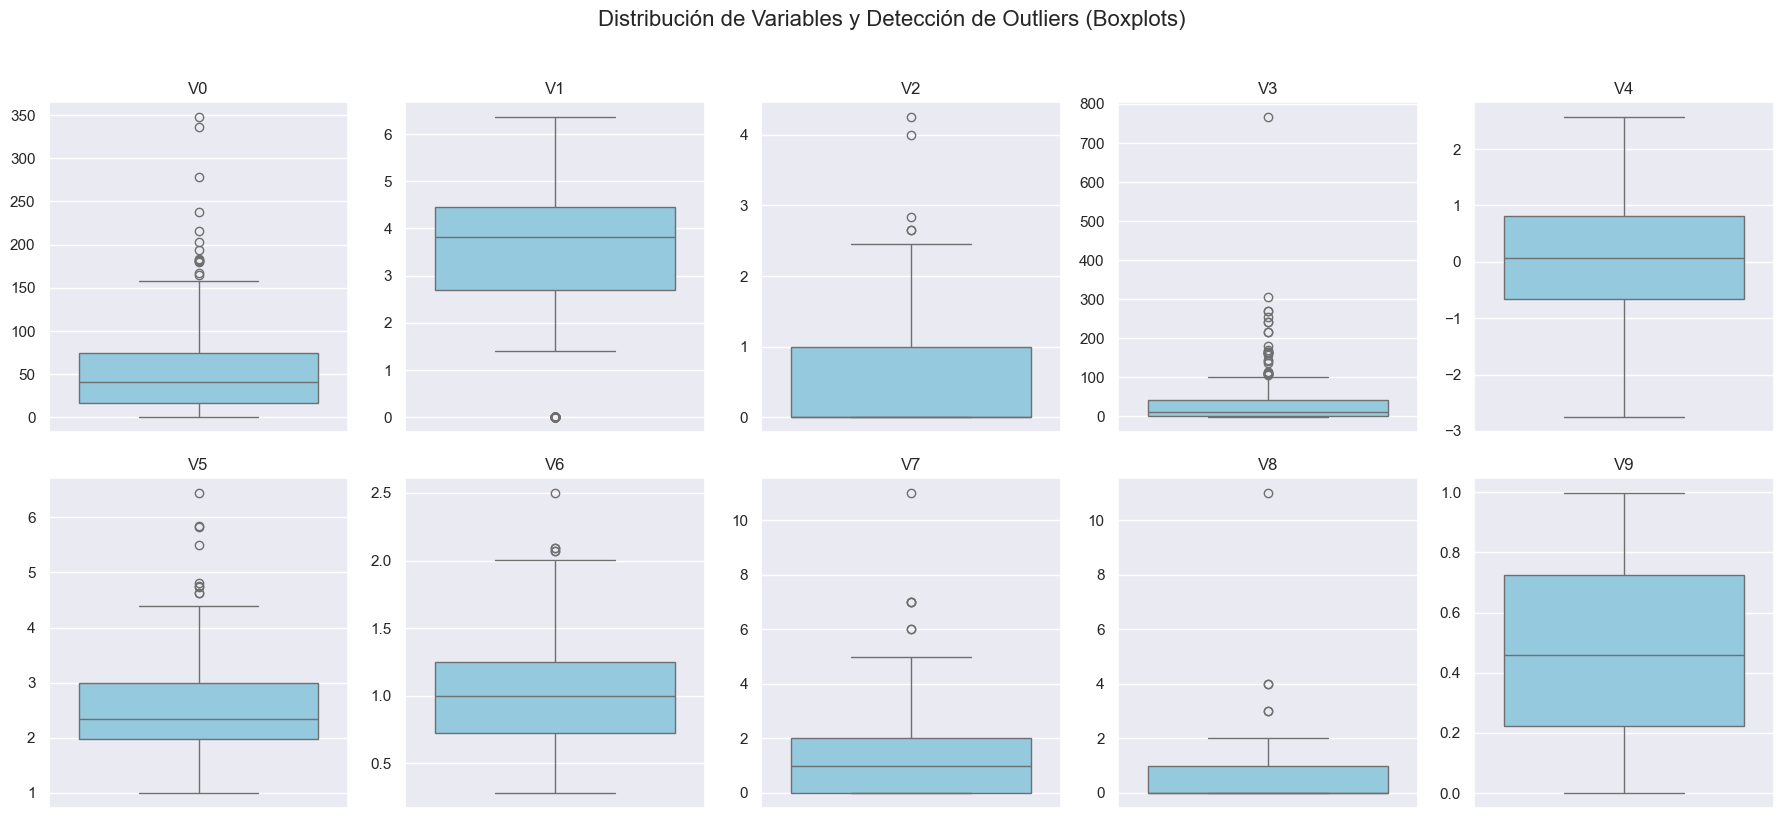

In [5]:
# 1. Select only the input numerical features (exclude the 'target' variable)
# Note: 'deseada' is the target variable name in the raw dataset
features_to_plot = ['V0', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9']

# 2. Set up the canvas: a grid of 2 rows and 5 columns
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(18, 8))
fig.suptitle('Distribución de Variables y Detección de Outliers (Boxplots)', fontsize=16, y=1.02)

# 3. Draw each boxplot iterating over our features
for ax, feature in zip(axes.flatten(), features_to_plot):
    sns.boxplot(y=df_raw[feature], ax=ax, color='skyblue')
    ax.set_title(feature)
    ax.set_ylabel('') # Remove Y-axis label for a cleaner look

# 4. Adjust spacing
plt.tight_layout()
plt.show()

### 2.3. Missing Values Analysis | Análisis de Nulos | Analyse fehlender Werte

🇬🇧 **EN:** We analyze the exact count and percentage of missing data per feature to determine the best imputation strategy.

🇪🇸 **ES:** Analizamos el recuento exacto y el porcentaje de datos faltantes por variable para determinar la mejor estrategia de imputación.

🇩🇪 **DE:** Wir analysieren die genaue Anzahl und den Prozentsatz fehlender Daten pro Merkmal, um die beste Imputationsstrategie festzulegen.

In [6]:
# Create a summary table exclusively for missing values
missing_data = pd.DataFrame({
    'Total Missing': df_raw.isnull().sum(),
    'Percentage': (df_raw.isnull().sum() / len(df_raw) * 100).apply(lambda x: f"{x:.3f} %")
})

# Display only columns that actually have missing data
display(missing_data[missing_data['Total Missing'] > 0])

,Total Missing,Percentage
V1,71,16.284 %
V2,63,14.450 %
V3,68,15.596 %
V5,63,14.450 %
V6,70,16.055 %
V7,60,13.761 %
V8,68,15.596 %


## 3. Data Cleaning, Split & Pipeline | Limpieza, División y Pipeline | Datenbereinigung, Aufteilung & Pipeline

🇬🇧 **EN:** We applied the anti-leakage pipeline: train/test split → winsorisation → scaling → KNN imputation → ensemble with null indicators. The outliers in V7 and V8 (values 11, a single occurrence each in the training set) are preserved as they are: tree-based models are robust to rare values, and rewriting them would alter the original dataset without the owner’s authorisation.

🇪🇸 **ES:** Aplicamos la pipeline anti-leakage: train/test split → winsorización → escalado → imputación KNN → ensamblaje con indicadores de nulo. Los outliers de V7 y V8 (valores 11, una sola ocurrencia cada uno en train) se preservan tal cual: los modelos basados en árboles son robustos a valores raros, y reescribirlos sería alterar el dataset original sin autorización del propietario.

🇩🇪 **DE:** Wir wenden die Anti-Leakage-Pipeline an: Train-Test-Aufteilung → Winsorisierung → Skalierung → KNN-Imputation → Zusammenführung mit Null-Indikatoren. Die Ausreißer von V7 und V8 (Werte 11, jeweils ein einziges Vorkommen im Trainingsdatensatz) bleiben unverändert: Baum-basierte Modelle sind robust gegenüber seltenen Werten, und eine Neuschreibung würde eine unbefugte Veränderung des ursprünglichen Datensatzes ohne Zustimmung des Eigentümers bedeuten.

In [7]:
df_clean = df_raw.copy()

# ==========================================
# 2.5. MISSING INDICATORS (Anti-Data-Loss Feature Engineering)
# ==========================================
# For sensor data, a missing value is not random noise — it may indicate
# a sensor fault, an operational state, or a measurement limit.
# We capture this information as binary flags BEFORE imputation erases it.
# This must be done BEFORE the train/test split so both sets are consistent.

cols_with_nulls = ['V0', 'V1', 'V2', 'V3', 'V5', 'V6', 'V7', 'V8']

for col in cols_with_nulls:
    df_clean[f'{col}_null'] = df_clean[col].isnull().astype(int)

print("Missing indicator features added:")
print(df_clean[[f'{col}_null' for col in cols_with_nulls]].sum().to_string())
print(f"\nNew dataset shape: {df_clean.shape}")

# 2. THE CRITICAL MOMENT: Train/Test split before transforming
# Separate Features (X) and Target (y)
X = df_clean.drop('deseada', axis=1)
y = df_clean['deseada']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train = X_train.copy()
X_test = X_test.copy()
print(f"Training rows (Train): {X_train.shape[0]} | Validation rows (Test): {X_test.shape[0]}\n")


# ==========================================
# 3. TRANSFORMATION PHASE (ANTI-LEAKAGE)
# ==========================================

base_features = ['V0', 'V1', 'V2', 'V3', 'V5', 'V6', 'V7', 'V8']
null_indicator_cols = [f'{col}_null' for col in cols_with_nulls]
features = base_features + null_indicator_cols   # full feature list for the model

# 3.1. Winsorization (only on continuous columns, never on indicators)
limit_v0_train = X_train['V0'].quantile(0.95)
limit_v3_train = X_train['V3'].quantile(0.95)

X_train['V0'] = X_train['V0'].clip(upper=limit_v0_train)
X_train['V3'] = X_train['V3'].clip(upper=limit_v3_train)
X_test['V0']  = X_test['V0'].clip(upper=limit_v0_train)
X_test['V3']  = X_test['V3'].clip(upper=limit_v3_train)

# 3.2. Scale + Impute ONLY the base numeric features (indicators stay clean)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[base_features])
X_test_scaled  = scaler.transform(X_test[base_features])

knn_imputer = KNNImputer(n_neighbors=3)
X_train_imp = knn_imputer.fit_transform(X_train_scaled)
X_test_imp  = knn_imputer.transform(X_test_scaled)

X_train_num = scaler.inverse_transform(X_train_imp)
X_test_num  = scaler.inverse_transform(X_test_imp)

# 3.3. Reassemble: numeric columns + null indicators (kept untouched)
df_train_clean = pd.concat([
    pd.DataFrame(X_train_num, columns=base_features),
    X_train[null_indicator_cols].reset_index(drop=True)
], axis=1)

df_test_clean = pd.concat([
    pd.DataFrame(X_test_num, columns=base_features),
    X_test[null_indicator_cols].reset_index(drop=True)
], axis=1)

y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Pipeline OK. Train: {df_train_clean.shape} | Test: {df_test_clean.shape}")
print(f"Null indicators clean (0/1): {df_train_clean['V1_null'].unique()}")

Missing indicator features added:
V0_null     0
V1_null    71
V2_null    63
V3_null    68
V5_null    63
V6_null    70
V7_null    60
V8_null    68

New dataset shape: (436, 19)
Training rows (Train): 348 | Validation rows (Test): 88

Pipeline OK. Train: (348, 16) | Test: (88, 16)
Null indicators clean (0/1): [0 1]


## 4. Modeling & Hyperparameter Tuning | Modelado y Ajuste de Hiperparámetros | Modellierung & Hyperparameter-Tuning

🇬🇧 **EN:** We evaluate two robust algorithms: **Random Forest** (as our baseline) and **Gradient Boosting**. Since our data distribution has changed after cleaning, we use `GridSearchCV` to systematically explore multiple hyperparameter combinations for the Gradient Boosting model. This automated search uses Cross-Validation to find the "sweet spot" that maximizes predictive power while strictly avoiding overfitting.

🇪🇸 **ES:** Evaluamos dos algoritmos robustos: **Random Forest** (como línea base) y **Gradient Boosting**. Dado que la distribución de nuestros datos ha cambiado tras la limpieza, utilizamos `GridSearchCV` para explorar sistemáticamente múltiples combinaciones de hiperparámetros para el Gradient Boosting. Esta búsqueda automatizada utiliza Validación Cruzada para encontrar el "punto dulce" que maximiza el poder predictivo evitando estrictamente el sobreajuste.

🇩🇪 **DE:** Wir evaluieren zwei robuste Algorithmen: **Random Forest** (als Baseline) und **Gradient Boosting**. Da sich unsere Datenverteilung nach der Bereinigung geändert hat, verwenden wir `GridSearchCV`, um systematisch mehrere Hyperparameter-Kombinationen für das Gradient Boosting-Modell zu untersuchen. Diese automatisierte Suche nutzt Kreuzvalidierung, um den "Sweet Spot" zu finden, der die Vorhersagekraft maximiert und gleichzeitig Overfitting strikt vermeidet.

In [8]:
# 2. Define the hyperparameter grid for Gradient Boosting and Random Forest
gb_param_grid = {
    'n_estimators': [50, 100, 200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 3, 4, 5]
}

rf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_features': ['sqrt', 0.5, 0.7],
    'min_samples_leaf': [1, 2, 3],
    'max_depth': [None, 10, 20]
}

# 3. Configure the Grid Search with 5-fold Cross-Validation
print("Initiating Grid Search for Gradient Boosting. This may take a few seconds...")
gb_grid_search = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=gb_param_grid,
    cv=5, # 5 internal mock exams for each combination
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Use all computer processors
)

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=5, # 5 internal mock exams for each combination
    scoring='neg_mean_squared_error',
    n_jobs=-1 # Use all computer processors
)

# 4. Train the baseline and the Grid Search
rf_grid.fit(df_train_clean, y_train)
gb_grid_search.fit(df_train_clean, y_train)

# 5. Extract the absolute best model found by the Grid Search
best_gb_model = gb_grid_search.best_estimator_
best_rf_model = rf_grid.best_estimator_

print(f"Grid Search completed! Best parameters found for Gradient Boosting: {gb_grid_search.best_params_}")
print(f"Best parameters found for Random Forest: {rf_grid.best_params_}")

# 6. Make predictions on the isolated Test set
rf_predictions = best_rf_model.predict(df_test_clean)
gb_predictions = best_gb_model.predict(df_test_clean)

# 7. Calculate the final scores (MSE)
rf_mse = mean_squared_error(y_test, rf_predictions)
gb_mse = mean_squared_error(y_test, gb_predictions)

print("--- MOCK EXAM RESULTS (MSE) ---")
print(f"Random Forest (Grid Optimized):     {rf_mse:.4f}")
print(f"Gradient Boosting (Grid Optimized): {gb_mse:.4f}")

Initiating Grid Search for Gradient Boosting. This may take a few seconds...
Grid Search completed! Best parameters found for Gradient Boosting: {'learning_rate': 0.05, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best parameters found for Random Forest: {'max_depth': 10, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 500}
--- MOCK EXAM RESULTS (MSE) ---
Random Forest (Grid Optimized):     1.3155
Gradient Boosting (Grid Optimized): 1.3353


In [9]:
# ==========================================
# 4.1. PERMUTATION IMPORTANCE — Noise-feature detection
# ==========================================
# feature_importances_ de RF está sesgada hacia variables continuas
# de alta cardinalidad (V4 y V9 lo son), por eso usamos permutation_importance:
# mide la caída real de MSE cuando barajamos aleatoriamente cada columna.
# Una feature cuya importancia tiene IC del 95% que cruza el cero es indistinguible de ruido.

def permutation_report(model, X_val, y_val, model_name, n_repeats=30):
    result = permutation_importance(
        model,
        X_val,
        y_val,
        n_repeats=n_repeats,
        scoring='neg_mean_squared_error',
        random_state=42,
        n_jobs=-1,
    )
    df = pd.DataFrame({
        'feature': X_val.columns,
        'importance_mean': result.importances_mean,
        'importance_std':  result.importances_std,
    })
    # Una feature es "sospechosa de ruido" si su CI inferior (~mean - 2*std) <= 0
    df['ci_low']        = df['importance_mean'] - 2 * df['importance_std']
    df['noise_suspect'] = df['ci_low'] <= 0
    df = df.sort_values('importance_mean', ascending=False).reset_index(drop=True)
    print(f"\n=== {model_name} ===")
    display(df.round(4))
    suspects = df.loc[df['noise_suspect'], 'feature'].tolist()
    print(f"Candidatas a descartar ({model_name}): {suspects}")
    return df

perm_rf = permutation_report(best_rf_model, df_test_clean, y_test, "Random Forest")
perm_gb = permutation_report(best_gb_model, df_test_clean, y_test, "Gradient Boosting")

# Solo descartar variables marcadas como ruido por AMBOS modelos
# (criterio conservador: si solo un modelo la marca, podría ser idiosincrasia del modelo)
common_noise = set(perm_rf.loc[perm_rf['noise_suspect'], 'feature']) & \
               set(perm_gb.loc[perm_gb['noise_suspect'], 'feature'])
print(f"\n>>> Variables marcadas como ruido por AMBOS modelos: {sorted(common_noise)}")


=== Random Forest ===


,feature,importance_mean,importance_std,ci_low,noise_suspect
0,V5,0.6520,0.1282,0.3956,False
1,V0,0.6026,0.1158,0.3709,False
2,V3,0.5289,0.1014,0.3260,False
3,V6,0.4912,0.0926,0.3060,False
4,V2,0.1829,0.0848,0.0132,False
5,V1,0.1788,0.0529,0.0731,False
6,V7,0.0243,0.0351,-0.0458,True
7,V8,0.0083,0.0163,-0.0243,True
8,V5_null,0.0079,0.0029,0.0021,False
9,V7_null,0.0020,0.0063,-0.0105,True


Candidatas a descartar (Random Forest): ['V7', 'V8', 'V7_null', 'V0_null', 'V3_null', 'V6_null', 'V8_null', 'V1_null', 'V2_null']

=== Gradient Boosting ===


,feature,importance_mean,importance_std,ci_low,noise_suspect
0,V0,0.9553,0.2164,0.5225,False
1,V3,0.6204,0.1590,0.3024,False
2,V5,0.5555,0.1129,0.3298,False
3,V6,0.4372,0.1257,0.1858,False
4,V1,0.2729,0.1053,0.0622,False
5,V7,0.1265,0.0649,-0.0033,True
6,V2,0.1225,0.0550,0.0126,False
7,V6_null,0.0047,0.0086,-0.0124,True
8,V2_null,0.0032,0.0047,-0.0062,True
9,V8_null,0.0021,0.0008,0.0006,False


Candidatas a descartar (Gradient Boosting): ['V7', 'V6_null', 'V2_null', 'V7_null', 'V3_null', 'V5_null', 'V0_null', 'V8', 'V1_null']

>>> Variables marcadas como ruido por AMBOS modelos: ['V0_null', 'V1_null', 'V2_null', 'V3_null', 'V6_null', 'V7', 'V7_null', 'V8']


## 5. Final Prediction & Export | Predicción Final y Exportación | Finale Vorhersage & Export

### 5.1. Full Data Retraining | Retrenamiento al 100% | Neuschulung mit 100% der Daten

🇬🇧 **EN:** We applied the definitive strategy: an ensemble (average) of Random Forest and Gradient Boosting models retrained on 100% of the data. The difference in CV MSE between the two models is smaller than the noise between folds (0.012 vs. fold standard deviation ~0.15), so averaging is more robust than choosing just one.

🇪🇸 **ES:** Aplicamos la estrategia definitiva: ensemble (promedio) de Random Forest y Gradient Boosting reentrenados con el 100% de los datos. La diferencia de CV MSE entre ambos modelos es menor que el ruido entre folds (0,012 vs std de fold ~0,15), por lo que promediar es más robusto que escoger uno.

🇩🇪 **DE:** Wir wenden die endgültige Strategie an: ein Ensemble (Durchschnitt) aus Random Forest und Gradient Boosting, die mit 100 % der Daten neu trainiert wurden. Der Unterschied im CV-MSE zwischen den beiden Modellen ist geringer als die Streuung zwischen den Folds (0,012 gegenüber einer Standardabweichung pro Fold von ~0,15), weshalb die Mittelwertbildung robuster ist als die Auswahl eines einzelnen Modells.

In [10]:
X_full = df_clean[base_features].copy()   # solo numéricas
y_full = df_clean['deseada']
null_full = df_clean[null_indicator_cols].copy()  # indicadores aparte

# Winsorization
limit_v0_full = X_full['V0'].quantile(0.95)
limit_v3_full = X_full['V3'].quantile(0.95)
X_full['V0'] = X_full['V0'].clip(upper=limit_v0_full)
X_full['V3'] = X_full['V3'].clip(upper=limit_v3_full)

# Scale + Impute + Inverse (solo numéricas)
full_scaler = StandardScaler()
X_full_scaled = full_scaler.fit_transform(X_full)
full_knn = KNNImputer(n_neighbors=3)
X_full_imp = full_knn.fit_transform(X_full_scaled)
X_full_final = full_scaler.inverse_transform(X_full_imp)

# Reunir numéricas + indicadores
df_full_clean = pd.concat([
    pd.DataFrame(X_full_final, columns=base_features),
    null_full.reset_index(drop=True)
], axis=1)

rf_cv_mse = -rf_grid.best_score_
gb_cv_mse = -gb_grid_search.best_score_

print(f"RF  Best CV MSE : {rf_cv_mse:.4f}")
print(f"GB  Best CV MSE : {gb_cv_mse:.4f}")

RF  Best CV MSE : 1.3580
GB  Best CV MSE : 1.3770


### 5.2. Blind Test Processing & Prediction | Procesamiento y Predicción del Examen Ciego | Blinde Testverarbeitung & Vorhersage

🇬🇧 **EN:** We load the blind test dataset provided by the examiners. Crucially, we must treat this data exactly like our validation set: transforming it using *only* the mathematical rules learned in the previous step to guarantee zero Data Leakage.

🇪🇸 **ES:** Cargamos el conjunto de datos ciego proporcionado por los examinadores. Es crucial tratar estos datos exactamente igual que nuestro conjunto de validación: transformándolo usando *únicamente* las reglas matemáticas aprendidas en el paso anterior para garantizar cero Fugas de Datos.

🇩🇪 **DE:** Wir laden den von den Prüfern bereitgestellten blinden Testdatensatz. Es ist entscheidend, diese Daten genau wie unseren Validierungsdatensatz zu behandeln: Transformieren sie *ausschließlich* mit den im vorherigen Schritt erlernten mathematischen Regeln, um Data Leakage zu vermeiden.

In [11]:
# 1. Load blind test from Excel
df_blind = pd.read_excel('test_competicion_entradas.xlsx')

# 3. Create missing indicators BEFORE imputation (same as training)
for col in cols_with_nulls:
    df_blind[f'{col}_null'] = df_blind[col].isnull().astype(int)

print("Missing indicators applied to blind test. ✓")

# 4. Separate numeric features and indicators
X_blind    = df_blind[base_features].copy()
null_blind = df_blind[null_indicator_cols].copy()

# 5. Apply pipeline (ONLY .transform — no .fit)
X_blind['V0'] = X_blind['V0'].clip(upper=limit_v0_full)
X_blind['V3'] = X_blind['V3'].clip(upper=limit_v3_full)

X_blind_scaled  = full_scaler.transform(X_blind)
X_blind_imp     = full_knn.transform(X_blind_scaled)
X_blind_final   = full_scaler.inverse_transform(X_blind_imp)

# 6. Reassemble with clean indicators
df_blind_clean = pd.concat([
    pd.DataFrame(X_blind_final, columns=base_features),
    null_blind.reset_index(drop=True)
], axis=1)

# 7. Generate predictions
# Reentrenar AMBOS con 100% de datos y promediar predicciones
rf_full = RandomForestRegressor(**rf_grid.best_params_, random_state=42)
gb_full = GradientBoostingRegressor(**gb_grid_search.best_params_, random_state=42)
rf_full.fit(df_full_clean, y_full)
gb_full.fit(df_full_clean, y_full)
rf_pred = rf_full.predict(df_blind_clean)
gb_pred = gb_full.predict(df_blind_clean)
final_predictions = (rf_pred + gb_pred) / 2
print(f"Ensemble RF+GB ready. ({len(final_predictions)} rows)")

Missing indicators applied to blind test. ✓
Ensemble RF+GB ready. (110 rows)


### 5.3. Exporting Results | Exportación de Resultados | Exportieren der Ergebnisse

🇬🇧 **EN:** We format the predictions as requested by the stakeholders (a single-column Excel file named with the candidate's surname) ensuring it is ready for final deployment and ranking evaluation.

🇪🇸 **ES:** Formateamos las predicciones tal y como han solicitado los *stakeholders* (un archivo Excel de una sola columna nombrado con el apellido del candidato), asegurando que esté listo para el despliegue final y la evaluación del ranking.

🇩🇪 **DE:** Wir formatieren die Vorhersagen wie von den Stakeholdern gewünscht (eine einspaltige Excel-Datei, die nach dem Nachnamen des Kandidaten benannt ist) und stellen sicher, dass sie für die finale Bewertung bereit ist.

In [12]:
# 1. Save in the format required by stakeholders
final_answers = pd.DataFrame(final_predictions, columns=['deseada'])

# 2. Generate current timestamp (Format: YYYYMMDD_HHMMSS)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Format the filename
file_name = f"Predicciones_Riquelme_{timestamp}.xlsx"
final_answers.to_excel(file_name, index=False)

print(f"Mission accomplished! File ready to be sent: {file_name}")

Mission accomplished! File ready to be sent: Predicciones_Riquelme_20260614_140050.xlsx


In [13]:
df_check = pd.read_excel(file_name)
print(f"Filas: {len(df_check)} (esperado: 110)")
print(f"Columnas: {list(df_check.columns)} (esperado: ['deseada'])")
print(f"Rango: [{df_check['deseada'].min():.3f}, {df_check['deseada'].max():.3f}]")
print(f"Mean/Std: {df_check['deseada'].mean():.3f} / {df_check['deseada'].std():.3f}")
print(f"NaN: {df_check['deseada'].isna().sum()}")

Filas: 110 (esperado: 110)
Columnas: ['deseada'] (esperado: ['deseada'])
Rango: [1.539, 7.025]
Mean/Std: 4.483 / 1.123
NaN: 0
